In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/clf_mixer_attnpl_t_20260125-133053") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'resume_path': './checkpoints/mixer_tpp_20260125-132634/last_model_1.pth', 'load_specific_parts': ['encoder'], 'model': 'clf_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.0006, 'weight_decay': 0.001, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06,

OptimizedModule(
  (_orig_mod): TaskModel(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_linear): Linear(in_features=1, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
              (fc1): Linear(in_features=64, out_features=256, bias=False)
              (fc2): Linear(in_features=128, out_features=64, bias=False)
            )
         

In [3]:
model.eval()
model.extractor.g

Parameter containing:
tensor([0.0552, 0.0107, 0.0006, 0.0123], device='cuda:0', requires_grad=True)

In [4]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
Catalog statistics: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
stas {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
[✔] Loading cached data from: ../data/ChuanDian/processed/classifier/classifier_Mc_3_Mf_4.5_Tfore_30_Twindow_180_context

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [6]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

Positive samples: 836, Negative samples: 594
Total samples: 1430, Positive ratio: 0.58, Negative ratio: 0.42


In [7]:
for x, y in val_loader:
    x, y = x.to(device), y.to(device)
    break

In [8]:
model.base_model.encoder.layers[2]


Block(
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mixer): Mamba2Rotary(
    (in_proj): Linear(in_features=64, out_features=514, bias=False)
    (act): SiLU()
    (norm): RMSNorm()
    (out_proj): Linear(in_features=128, out_features=64, bias=False)
    (rotary_emb): RotaryEmbeddingTime()
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mlp): GatedMLP(
    (fc1): Linear(in_features=64, out_features=256, bias=False)
    (fc2): Linear(in_features=128, out_features=64, bias=False)
  )
)

In [9]:
# model.base_model.input_adapter(x)['features'][0,:,0]

In [10]:
# x[0, :, 1]*args.Twindow/1.3
# model.base_model.input_adapter(x)['times']

In [11]:
model.eval()
model.extractor.t_mlp.to(device)
x = torch.linspace(0, 1, 100).unsqueeze(1)  
x = x.to(device)  
gamma, beta = model.extractor.t_mlp(x).chunk(2, dim=-1)  

In [12]:
def predict_all(model, data_loader, device, return_X=False):
    y_pred_list = []
    y_list = []
    X_list = [] if return_X else None

    model.eval()
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            if return_X:
                X = model.get_pooled_representation(x)
                X_list.append(X.detach().cpu())
            y_pred = model(x)
            y_pred_list.append(y_pred.detach().cpu())
            y_list.append(y.detach().cpu())

    y_pred_all = torch.cat(y_pred_list, dim=0).cpu().numpy()
    # flatten if shape is (N,1)
    if y_pred_all.ndim == 2 and y_pred_all.shape[1] == 1:
        y_pred_all = y_pred_all.squeeze(1)
    y_all = torch.cat(y_list, dim=0).cpu().numpy()

    if return_X:
        X_all = torch.cat(X_list, dim=0).cpu().numpy()
        return y_pred_all,  y_all, X_all
    return y_pred_all, y_all, None

In [13]:
from src.utils.metrics import classification_metrics, log_metrics, plot_and_save_roc_curve, plot_classification_distribution
y_pred_all, y_all, X_all = predict_all(model,val_loader, device, return_X=True)
start=0
end =400
classification_metrics(y_all[start:end], y_pred_all[start:end])  

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


{'precision': 0.75,
 'recall': 0.7951807228915663,
 'f1': 0.7719298245614035,
 'auc': 0.795582329317269,
 'fpr': 0.36666666666666664,
 'tpr': 0.7951807228915663,
 'R': 0.42851405622489963,
 'conf': 1.0,
 'threshold': 0.34790098667144775}

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

X = X_all
y = y_all
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=0)
rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.8
              precision    recall  f1-score   support

         0.0     0.7143    0.8333    0.7692         6
         1.0     0.8750    0.7778    0.8235         9

    accuracy                         0.8000        15
   macro avg     0.7946    0.8056    0.7964        15
weighted avg     0.8107    0.8000    0.8018        15

ROC AUC: 0.8148148148148148


In [15]:
# plt.plot(y_pred_all)
y_pred_all_nl = (y_pred_all - y_pred_all.min()) / (y_pred_all.max() - y_pred_all.min())

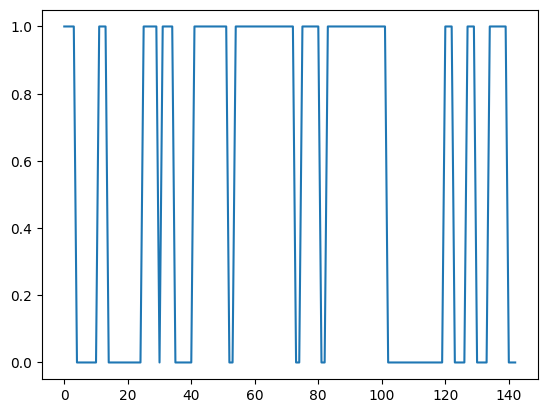

In [16]:
plt.plot(y_all,)
# plt.plot(y_pred_all_nl>0.5)
# plt.plot(y_pred_all_nl)

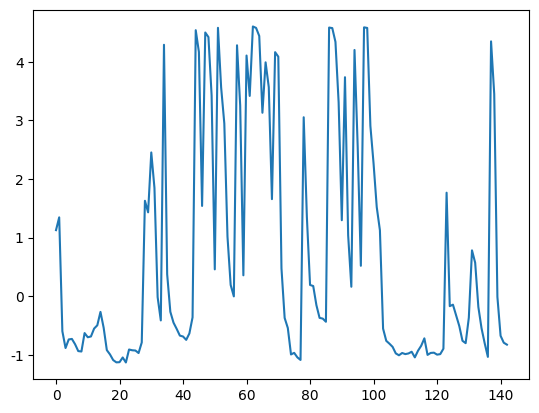

In [17]:
plt.plot(y_pred_all)